In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load review-level LLM mismatch scores
am_llm = pd.read_csv("../Mismatch_Score/am_llm_mismatch_score.csv")
print(f"Loaded llm_mismatch_score: {len(am_llm)} rows, {len(am_llm.columns)} columns")

ny_llm = pd.read_csv("../Mismatch_Score/new_ny_llm_mismatch_score.csv")
print(f"Loaded llm_mismatch_score: {len(ny_llm)} rows, {len(ny_llm.columns)} columns")

mo_llm = pd.read_csv("../Mismatch_Score/mo_llm_mismatch_score.csv")
print(f"Loaded llm_mismatch_score: {len(mo_llm)} rows, {len(mo_llm.columns)} columns")

Loaded llm_mismatch_score: 152146 rows, 54 columns
Loaded llm_mismatch_score: 13557 rows, 54 columns
Loaded llm_mismatch_score: 140236 rows, 54 columns


In [3]:
delta_cols = [f"delta_S{i:02d}" for i in range(1, 11)]
am_llm['avg_delta'] = am_llm[delta_cols].mean(axis=1)
ny_llm['avg_delta'] = ny_llm[delta_cols].mean(axis=1)
mo_llm['avg_delta'] = mo_llm[delta_cols].mean(axis=1)

In [4]:
am_llm.columns

Index(['listing_id', 'review_id', 'listing_name', 'description', 'review',
       'rating', 'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'neighborhood',
       'price', 'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'availability_eoy', 'row_idx', 'desc_S01_score',
       'desc_S02_score', 'desc_S03_score', 'desc_S04_score', 'desc_S05_score',
       'desc_S06_score', 'desc_S07_score', 'desc_S08_score', 'desc_S09_score',
       'desc_S10_score', 'rev_S01_score', 'rev_S02_score', 'rev_S03_score',
       'rev_S04_score', 'rev_S05_score', 'rev_S06_score', 'rev_S07_score',
       'rev_S08_score', 'rev_S09_score', 'rev_S10_score', 'mismatch_proxy',
       'mabs', 'mover', 'munder', 'delta_S01', 'delta_S02', 'delta_S03',
       'delta_S04', 'delta_S05', 'delta_S06', 'delta_S07', 'delta_S08',
       'delta_S09', 'delta_S10', 'avg_d

In [13]:
# Aggregate df_llm to listing level
def agg_to_listing(df_llm):
    delta_cols = [f"delta_S{i:02d}" for i in range(1, 11)]

    # Listing-level constants: take first (these don't vary across reviews of the same listing)
    # Review-level mismatch metrics: take mean
    agg_dict = {
        # Mismatch metrics (mean only, no std needed)
        "mabs": "mean",
        "mover": "mean",
        "munder": "mean",
        "avg_delta": "mean",
        "mismatch_proxy": "mean",
        # Guest rating (review-level, average per listing)
        "rating": "mean",
        # Review count
        "review_id": "count",
        # Listing-level attributes (same across all reviews, take first)
        "price": "first",
        "availability_30": "first",
        "availability_90": "first",
        "availability_365": "first",
        # Detailed review score dimensions (listing-level)
        "review_scores_accuracy": "first",
        "review_scores_cleanliness": "first",
        "review_scores_checkin": "first",
        "review_scores_communication": "first",
        "review_scores_location": "first",
        "review_scores_value": "first",
        # Neighborhood (categorical, listing-level)
        "neighborhood": "first",
    }

    # Per-dimension delta means
    for col in delta_cols:
        agg_dict[col] = "mean"

    df_listing = df_llm.groupby("listing_id").agg(agg_dict).reset_index()

    # Rename columns cleanly
    df_listing.columns = (
        ["listing_id",
         "mabs_mean", "mover_mean", "munder_mean", "avg_delta_mean", "proxy_mean",
         "rating_mean", "review_count",
         "price", "avail_30", "avail_90", "avail_365",
         "review_scores_accuracy", "review_scores_cleanliness",
         "review_scores_checkin", "review_scores_communication",
         "review_scores_location", "review_scores_value",
         "neighborhood"]
        + [f"{col}_mean" for col in delta_cols]
    )

    print(f"Aggregated to listing level: {len(df_listing)} listings")
    print(f"Columns: {list(df_listing.columns)}")

    # Log transforms for right-skewed continuous variables
    df_listing["log_review_count"] = np.log1p(df_listing["review_count"])
    df_listing["log_price"] = np.log1p(df_listing["price"])
    # Availability is bounded [0, 365], not heavily skewed — keep raw values
    # Derived availability features capture booking-pressure spread
    df_listing["avail_diff_365_30"] = df_listing["avail_365"] - df_listing["avail_30"]
    df_listing["avail_diff_90_30"]  = df_listing["avail_90"]  - df_listing["avail_30"]

    return df_listing

In [14]:
# Aggregate all three cities to listing level
am_listing = agg_to_listing(am_llm)
ny_listing = agg_to_listing(ny_llm)
mo_listing = agg_to_listing(mo_llm)

datasets = {'NY': ny_listing, 'AM': am_listing, 'MO': mo_listing}

Aggregated to listing level: 4113 listings
Columns: ['listing_id', 'mabs_mean', 'mover_mean', 'munder_mean', 'avg_delta_mean', 'proxy_mean', 'rating_mean', 'review_count', 'price', 'avail_30', 'avail_90', 'avail_365', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'neighborhood', 'delta_S01_mean', 'delta_S02_mean', 'delta_S03_mean', 'delta_S04_mean', 'delta_S05_mean', 'delta_S06_mean', 'delta_S07_mean', 'delta_S08_mean', 'delta_S09_mean', 'delta_S10_mean']
Aggregated to listing level: 302 listings
Columns: ['listing_id', 'mabs_mean', 'mover_mean', 'munder_mean', 'avg_delta_mean', 'proxy_mean', 'rating_mean', 'review_count', 'price', 'avail_30', 'avail_90', 'avail_365', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'neighborhood', 'delta_S01_mean', 'delta_S02_mean

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Feature set used as predictors
NUMERIC_FEATURES = [
    'log_price',
    'avail_30', 'avail_90', 'avail_365',
    'avail_diff_365_30', 'avail_diff_90_30',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'rating_mean',
    'log_review_count',
]
TARGET_COL = 'log_mabs'

def prepare_features(df):
    df = df.copy()

    # Drop listings where mabs_mean == 0 (log is undefined)
    n_before = len(df)
    df = df[df['mabs_mean'] > 0].copy()
    if len(df) < n_before:
        print(f"  Dropped {n_before - len(df)} listings with mabs_mean = 0")

    # Log-transform target: mabs is right-skewed
    df[TARGET_COL] = np.log(df['mabs_mean'])

    # One-hot encode neighborhood (listing-level fixed effect)
    df = pd.get_dummies(df, columns=['neighborhood'], drop_first=True, dtype=int)
    neighborhood_cols = [c for c in df.columns if c.startswith('neighborhood_')]

    feature_cols = NUMERIC_FEATURES + neighborhood_cols

    # Drop rows with any NaN in features or target
    model_df = df[feature_cols + [TARGET_COL]].dropna()
    n_dropped = len(df) - len(model_df)
    if n_dropped > 0:
        print(f"  Dropped {n_dropped} rows with NaN in features")

    X = model_df[feature_cols]
    y = model_df[TARGET_COL]
    return X, y, feature_cols

In [16]:
# Model definitions
# RF: max_features='sqrt' ensures trees are decorrelated (standard RF practice)
# LightGBM: explicit num_leaves=31 since leaf-wise growth makes max_depth less meaningful
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_features='sqrt',
        random_state=42, n_jobs=-1,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
}

In [17]:
# 5-fold cross-validation for all cities and models
cv = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

for city, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"CITY: {city}")
    print(f"{'='*60}")

    X, y, feature_cols = prepare_features(df)
    print(f"  Listings: {len(X)}, Features: {X.shape[1]}")

    city_results = {}
    for model_name, model in models.items():
        scores = cross_validate(
            clone(model), X, y,
            cv=cv,
            scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
            return_train_score=False,
        )
        r2   = scores['test_r2']
        rmse = -scores['test_rmse']

        print(f"\n  {model_name}")
        print(f"    R²:   {r2.mean():.3f} ± {r2.std():.3f}  (per fold: {[f'{v:.3f}' for v in r2]})")
        print(f"    RMSE: {rmse.mean():.3f} ± {rmse.std():.3f}")

        city_results[model_name] = {
            'r2_mean': r2.mean(), 'r2_std': r2.std(),
            'rmse_mean': rmse.mean(), 'rmse_std': rmse.std(),
        }

    all_results[city] = city_results


CITY: NY
  Listings: 302, Features: 28

  Random Forest
    R²:   0.118 ± 0.231  (per fold: ['0.254', '0.374', '0.097', '0.171', '-0.306'])
    RMSE: 0.289 ± 0.018

  XGBoost
    R²:   0.063 ± 0.201  (per fold: ['0.184', '0.278', '0.055', '0.108', '-0.309'])
    RMSE: 0.299 ± 0.016

  LightGBM
    R²:   0.004 ± 0.340  (per fold: ['0.336', '0.389', '-0.209', '0.026', '-0.521'])
    RMSE: 0.304 ± 0.026

CITY: AM
  Listings: 4113, Features: 35

  Random Forest
    R²:   -0.025 ± 0.031  (per fold: ['-0.006', '-0.077', '-0.044', '-0.002', '0.001'])
    RMSE: 0.193 ± 0.008

  XGBoost
    R²:   -0.112 ± 0.040  (per fold: ['-0.111', '-0.175', '-0.118', '-0.109', '-0.049'])
    RMSE: 0.201 ± 0.009

  LightGBM
    R²:   -0.090 ± 0.028  (per fold: ['-0.088', '-0.138', '-0.054', '-0.098', '-0.072'])
    RMSE: 0.199 ± 0.009

CITY: MO
  Listings: 4743, Features: 45

  Random Forest
    R²:   0.133 ± 0.060  (per fold: ['0.197', '0.141', '0.196', '0.055', '0.074'])
    RMSE: 0.233 ± 0.016

  XGBoost


In [18]:
# Summary table
rows = []
for city, city_res in all_results.items():
    for model_name, res in city_res.items():
        rows.append({
            'City': city,
            'Model': model_name,
            'R² mean': round(res['r2_mean'], 3),
            'R² std':  round(res['r2_std'],  3),
            'RMSE mean': round(res['rmse_mean'], 3),
            'RMSE std':  round(res['rmse_std'],  3),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

City         Model  R² mean  R² std  RMSE mean  RMSE std
  NY Random Forest    0.118   0.231      0.289     0.018
  NY       XGBoost    0.063   0.201      0.299     0.016
  NY      LightGBM    0.004   0.340      0.304     0.026
  AM Random Forest   -0.025   0.031      0.193     0.008
  AM       XGBoost   -0.112   0.040      0.201     0.009
  AM      LightGBM   -0.090   0.028      0.199     0.009
  MO Random Forest    0.133   0.060      0.233     0.016
  MO       XGBoost    0.080   0.091      0.240     0.018
  MO      LightGBM    0.097   0.076      0.238     0.019


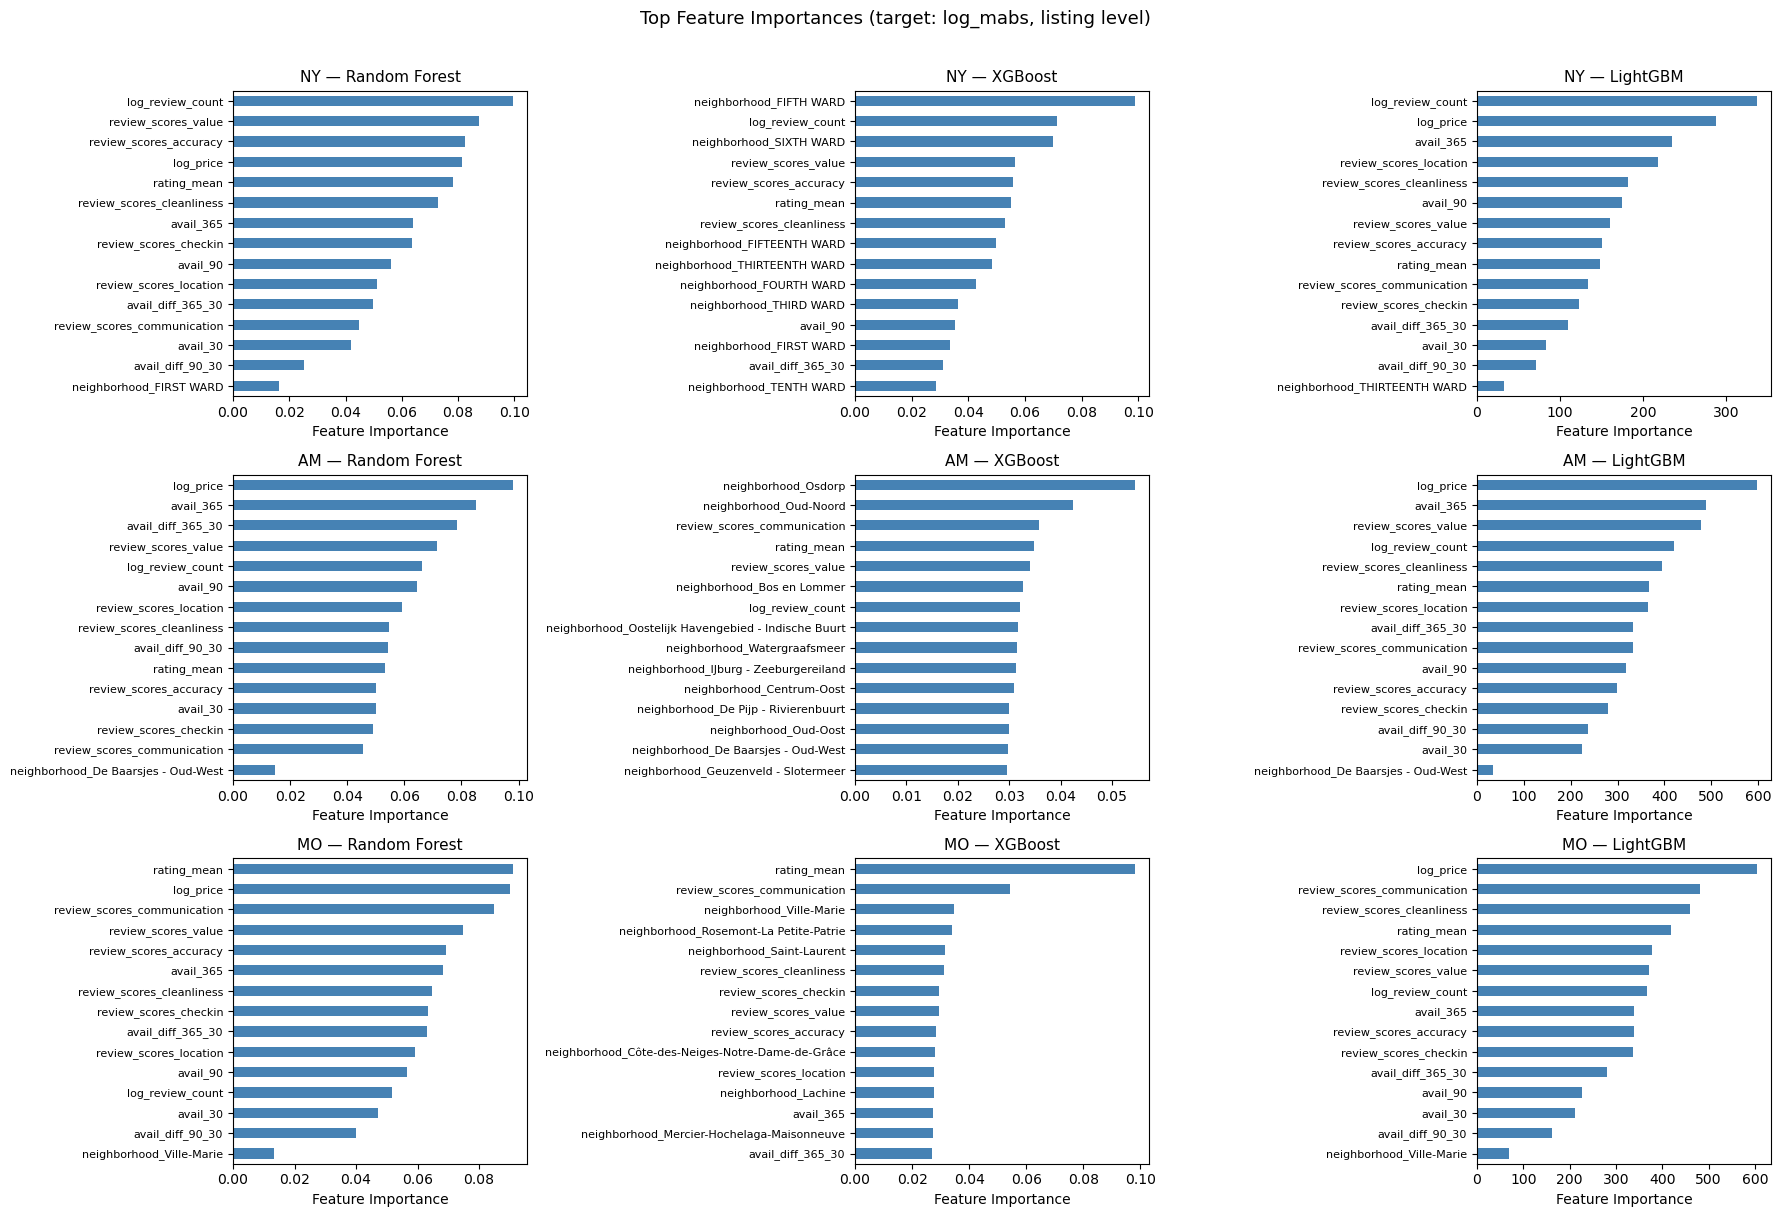

In [19]:
# Feature importance — refit each model on full data per city
TOP_N = 15
n_cities = len(datasets)
n_models = len(models)

fig, axes = plt.subplots(n_cities, n_models, figsize=(6 * n_models, 4 * n_cities))

for i, (city, df) in enumerate(datasets.items()):
    X, y, feature_cols = prepare_features(df)

    for j, (model_name, model) in enumerate(models.items()):
        fitted = clone(model)
        fitted.fit(X, y)

        importances = pd.Series(fitted.feature_importances_, index=feature_cols)
        top = importances.nlargest(TOP_N).sort_values()

        ax = axes[i][j]
        top.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f"{city} — {model_name}", fontsize=11)
        ax.set_xlabel("Feature Importance")
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Top Feature Importances (target: log_mabs, listing level)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("feature_importance_listing_level.png", dpi=150, bbox_inches='tight')
plt.show()